# DQN Tutorial-Style Training

Este notebook é o cockpit de treino e experimentação do `DQN`. Usa o pipeline tutorial-style com o ambiente local do projeto, permitindo iterar em curriculums, reward shaping, self-play e avaliação intermédia. Para demonstração do melhor modelo, usa o `04_dqn_best_model_showcase.ipynb`.


## Passo 1: Setup

A célula seguinte encontra a raiz do projeto, carrega a configuração e prepara os imports para treino, avaliação e visualização.

In [1]:
from __future__ import annotations

import copy
import json
import statistics
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import torch

ROOT = Path.cwd().resolve()
while not (ROOT / 'config.yaml').exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
if not (ROOT / 'config.yaml').exists():
    raise FileNotFoundError('Could not find project root containing config.yaml')
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

OUTPUTS = ROOT / 'outputs'
OUTPUTS.mkdir(parents=True, exist_ok=True)

from connect4_rl.agents.baselines import HeuristicAgent, RandomAgent, StrongHeuristicAgent, WeakHeuristicAgent
from connect4_rl.config import load_config
from connect4_rl.envs.connect_four import apply_action, initial_state, is_terminal, legal_actions, render_ascii
from connect4_rl.experiments import build_agent_from_checkpoint, build_agent_from_run, find_best_run
from connect4_rl.experiments.dqn_training import build_tutorial_dqn_lessons, evaluate_against_agent, train_dqn_self_play
from connect4_rl.experiments.notebook_variants import VARIANT_SPECS, apply_variant_to_config, prepare_variant_lessons_dir

CONFIG = load_config(ROOT / 'config.yaml')
NOTEBOOK_DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
if NOTEBOOK_DEVICE == 'cuda':
    torch.set_default_device(NOTEBOOK_DEVICE)

print({
    'torch_version': torch.__version__,
    'device': NOTEBOOK_DEVICE,
    'cuda_available': torch.cuda.is_available(),
    'outputs': str(OUTPUTS),
})


✓ Configuration validated successfully
{'torch_version': '2.11.0+cu130', 'device': 'cpu', 'cuda_available': False, 'outputs': '/home/vasco44/AR/outputs'}


## Passo 2: Configuração do treino

Aqui decides se queres lançar treino a partir do notebook. O perfil `quick` reduz `replay_buffer`, `batch_size` e número total de episódios para iteração rápida; o `full` usa um regime mais próximo do tutorial. O campo `experiment_variant` deixa testar hipóteses de melhoria sem mexer manualmente nos YAMLs base.


In [2]:
run_training = True
training_profile = 'full'  # 'quick' or 'full'
experiment_variant = 'baseline'  # 'baseline', 'strong_focus', 'safer_self_play', 'robust_selection'
seed = CONFIG.notebook_settings.seed

profile_settings = {
    'quick': {
        'episodes': 180,
        'eval_interval': 30,
        'eval_games': 12,
        'replay_buffer_size': 2000,
        'batch_size': 64,
        'min_replay_size': 64,
        'population_size': 2,
        'episodes_per_epoch': 2,
        'evo_epochs': 1,
        'evo_loop': 6,
        'max_steps_per_episode': 120,
    },
    'full': {
        'episodes': 1200,
        'eval_interval': 50,
        'eval_games': 24,
        'replay_buffer_size': 100000,
        'batch_size': 256,
        'min_replay_size': 256,
        'population_size': 1,
        'episodes_per_epoch': 10,
        'evo_epochs': 1,
        'evo_loop': 50,
        'max_steps_per_episode': 500,
    },
}

settings = profile_settings[training_profile]
variant_spec = VARIANT_SPECS[experiment_variant]
training_config = copy.deepcopy(CONFIG)
training_config.global_.seed = seed
training_config.global_.device = NOTEBOOK_DEVICE
training_config.dqn.episodes = settings['episodes']
training_config.dqn.eval_interval = settings['eval_interval']
training_config.dqn.eval_games = settings['eval_games']
training_config.dqn.replay_buffer_size = settings['replay_buffer_size']
training_config.dqn.batch_size = settings['batch_size']
training_config.dqn.min_replay_size = settings['min_replay_size']
training_config.dqn.population_size = settings['population_size']
training_config.dqn.episodes_per_epoch = settings['episodes_per_epoch']
training_config.dqn.evo_epochs = settings['evo_epochs']
training_config.dqn.evo_loop = settings['evo_loop']
training_config.dqn.max_steps_per_episode = settings['max_steps_per_episode']
training_config = apply_variant_to_config(training_config, experiment_variant)

variant_lessons_dir = prepare_variant_lessons_dir(ROOT, experiment_variant)
lesson4_config = next(lesson for lesson in build_tutorial_dqn_lessons(training_config.dqn.episodes, lessons_dir=variant_lessons_dir) if lesson.name == 'lesson4_self_play')

run_name = f'dqn_tutorial_{training_profile}_{experiment_variant}_seed_{seed}'
checkpoint_dir = OUTPUTS / run_name

{
    'run_training': run_training,
    'training_profile': training_profile,
    'experiment_variant': experiment_variant,
    'variant_description': variant_spec['description'],
    'run_name': run_name,
    'episodes_total': training_config.dqn.episodes,
    'eval_interval': training_config.dqn.eval_interval,
    'eval_games': training_config.dqn.eval_games,
    'replay_buffer_size': training_config.dqn.replay_buffer_size,
    'batch_size': training_config.dqn.batch_size,
    'population_size': training_config.dqn.population_size,
    'episodes_per_epoch': training_config.dqn.episodes_per_epoch,
    'evo_epochs': training_config.dqn.evo_epochs,
    'evo_loop': training_config.dqn.evo_loop,
    'random_opponent_fraction': training_config.dqn.random_opponent_fraction,
    'heuristic_opponent_fraction': training_config.dqn.heuristic_opponent_fraction,
    'checkpoint_score_heuristic_weight': training_config.dqn.checkpoint_score_heuristic_weight,
    'variant_lessons_dir': str(variant_lessons_dir),
    'lesson4_learning_rate_scale': lesson4_config.learning_rate_scale,
    'lesson4_epsilon_start': lesson4_config.epsilon_start,
    'lesson4_epsilon_end': lesson4_config.epsilon_end,
}


{'run_training': True,
 'training_profile': 'full',
 'experiment_variant': 'baseline',
 'variant_description': 'Configuração atual usada como referência.',
 'run_name': 'dqn_tutorial_full_baseline_seed_42',
 'episodes_total': 1200,
 'eval_interval': 50,
 'eval_games': 24,
 'replay_buffer_size': 100000,
 'batch_size': 256,
 'population_size': 1,
 'episodes_per_epoch': 10,
 'evo_epochs': 1,
 'evo_loop': 50,
 'random_opponent_fraction': 0.05,
 'heuristic_opponent_fraction': 0.45,
 'checkpoint_score_heuristic_weight': 6.0,
 'variant_lessons_dir': '/home/vasco44/AR/tmp/dqn_lessons_variants/baseline',
 'lesson4_learning_rate_scale': 0.25,
 'lesson4_epsilon_start': 0.2,
 'lesson4_epsilon_end': 0.02}

## Passo 3: Treino do pipeline DQN

Se `run_training = True`, o notebook executa o pipeline completo de lições e guarda os resultados em `outputs/<run_name>/`.

In [3]:
trained_agent = None
trained_metrics = None

if run_training:
    trained_agent, trained_metrics = train_dqn_self_play(training_config, checkpoint_dir=checkpoint_dir, lessons_dir=variant_lessons_dir)
    print({
        'curriculum_name': trained_metrics.curriculum_name,
        'experiment_variant': experiment_variant,
        'lessons': [item['lesson_name'] for item in trained_metrics.lesson_summaries],
        'final_checkpoint_path': trained_metrics.best_checkpoint_path,
        'last_eval': trained_metrics.evaluation[-1] if trained_metrics.evaluation else {},
        'loss_points': len(trained_metrics.losses),
    })
else:
    print('Training skipped. Set run_training = True to launch the tutorial-style DQN pipeline.')


✓ All random seeds set to 42
✓ All random seeds set to 42
✓ All random seeds set to 42
✓ All random seeds set to 42
{'curriculum_name': 'dqn_tutorial_pipeline', 'experiment_variant': 'baseline', 'lessons': ['lesson1_random', 'lesson2_weak', 'lesson3_strong', 'lesson4_self_play'], 'final_checkpoint_path': '/home/vasco44/AR/outputs/dqn_tutorial_full_baseline_seed_42/dqn_best.pt', 'last_eval': {'eval_opponent': 'strong', 'eval_mean_outcome': 0.36, 'vs_random_win_rate': 0.7916666666666666, 'vs_weak_heuristic_win_rate': 0.7083333333333334, 'vs_strong_heuristic_win_rate': 0.75, 'vs_heuristic_win_rate': 0.75, 'vs_previous_win_rate': 1.0, 'episode': 1132.0, 'lesson_name': 'lesson4_self_play', 'selection_score': 5.964166666666667}, 'loss_points': 8449}


## Passo 4: Resumo por lição

Este passo mostra como o treino evoluiu de `random` para `self_play` e quais foram as métricas finais de cada lição.

In [4]:
active_metrics = trained_metrics
active_agent = trained_agent
active_run_name = run_name if run_training else None
focus_checkpoint_path = None

if active_metrics is None:
    best_run = find_best_run(OUTPUTS, 'dqn')
    if best_run is None:
        raise RuntimeError('No DQN runs found under outputs/. Run training first or point the notebook to an existing run.')
    active_run_name = best_run.metrics_path.parent.name
    active_metrics = type('MetricsProxy', (), best_run.data)()
    focus_checkpoint_path = getattr(active_metrics, 'best_vs_strong_checkpoint_path', '') or best_run.data.get('best_checkpoint_path')
    active_agent = build_agent_from_checkpoint('dqn', focus_checkpoint_path, best_run.config, device=NOTEBOOK_DEVICE)
else:
    focus_checkpoint_path = getattr(active_metrics, 'best_vs_strong_checkpoint_path', '') or getattr(active_metrics, 'best_checkpoint_path', '')
    if focus_checkpoint_path:
        checkpoint_config = getattr(active_metrics, 'config', training_config.dqn.__dict__ if run_training else CONFIG.dqn.__dict__)
        active_agent = build_agent_from_checkpoint('dqn', focus_checkpoint_path, checkpoint_config, device=NOTEBOOK_DEVICE)

lesson_summaries = getattr(active_metrics, 'lesson_summaries', active_metrics.lesson_summaries if hasattr(active_metrics, 'lesson_summaries') else [])
evaluation = getattr(active_metrics, 'evaluation', [])
episode_rewards = getattr(active_metrics, 'episode_rewards', [])
epsilons = getattr(active_metrics, 'epsilons', [])

print({
    'run_name': active_run_name,
    'lessons': [item['lesson_name'] for item in lesson_summaries],
    'num_evaluations': len(evaluation),
    'focus_checkpoint_path': focus_checkpoint_path,
    'best_vs_strong_win_rate': round(float(getattr(active_metrics, 'best_vs_strong_win_rate', float('-inf'))), 4) if getattr(active_metrics, 'best_vs_strong_win_rate', None) is not None else None,
    'reward_first_20_mean': round(sum(episode_rewards[:20]) / max(len(episode_rewards[:20]), 1), 4),
    'reward_last_20_mean': round(sum(episode_rewards[-20:]) / max(len(episode_rewards[-20:]), 1), 4),
    'epsilon_first': round(epsilons[0], 6) if epsilons else None,
    'epsilon_last': round(epsilons[-1], 6) if epsilons else None,
})

lesson_summaries


{'run_name': 'dqn_tutorial_full_baseline_seed_42', 'lessons': ['lesson1_random', 'lesson2_weak', 'lesson3_strong', 'lesson4_self_play'], 'num_evaluations': 25, 'focus_checkpoint_path': '/home/vasco44/AR/outputs/dqn_tutorial_full_baseline_seed_42/dqn_best_vs_strong.pt', 'best_vs_strong_win_rate': 0.8333, 'reward_first_20_mean': -0.7, 'reward_last_20_mean': 0.6, 'epsilon_first': 1.0, 'epsilon_last': 0.041152}


[{'lesson_index': 1,
  'lesson_name': 'lesson1_random',
  'opponent': 'random',
  'eval_opponent': 'random',
  'episodes': 0,
  'best_score': 0.6,
  'best_checkpoint_path': '/home/vasco44/AR/outputs/dqn_tutorial_full_baseline_seed_42/lesson1_random/dqn_best.pt',
  'last_eval': {'eval_opponent': 'random',
   'eval_mean_outcome': 0.6,
   'vs_random_win_rate': 0.75,
   'vs_weak_heuristic_win_rate': 0.5416666666666666,
   'vs_strong_heuristic_win_rate': 0.041666666666666664,
   'vs_heuristic_win_rate': 0.041666666666666664,
   'vs_previous_win_rate': 0.0,
   'episode': 0.0,
   'lesson_name': 'lesson1_random'}},
 {'lesson_index': 2,
  'lesson_name': 'lesson2_weak',
  'opponent': 'weak',
  'eval_opponent': 'weak',
  'episodes': 109,
  'best_score': 2.3633333333333333,
  'best_checkpoint_path': '/home/vasco44/AR/outputs/dqn_tutorial_full_baseline_seed_42/lesson2_weak/dqn_best.pt',
  'last_eval': {'eval_opponent': 'weak',
   'eval_mean_outcome': 0.28,
   'vs_random_win_rate': 0.75,
   'vs_weak

## Passo 5: Curvas de avaliação

As curvas abaixo mostram a evolução do agente ao longo de todas as lições, já com os episódios encadeados num único eixo temporal.

Best vs strong checkpoint
{'episode': 982, 'lesson': 'lesson3_strong', 'vs_strong': 0.8333, 'eval_mean_outcome': 0.64, 'vs_random': 0.8333, 'vs_weak': 0.9167}
Evaluation checkpoints
{'episode': 0, 'lesson': 'lesson1_random', 'eval_mean_outcome': 0.6, 'vs_random': 0.75, 'vs_weak': 0.5417, 'vs_strong': 0.0417, 'vs_previous': 0.0}
{'episode': 50, 'lesson': 'lesson2_weak', 'eval_mean_outcome': 0.28, 'vs_random': 0.7083, 'vs_weak': 0.625, 'vs_strong': 0.0, 'vs_previous': 0.0}
{'episode': 100, 'lesson': 'lesson2_weak', 'eval_mean_outcome': 0.36, 'vs_random': 0.75, 'vs_weak': 0.5417, 'vs_strong': 0.0, 'vs_previous': 0.5}
{'episode': 109, 'lesson': 'lesson2_weak', 'eval_mean_outcome': 0.28, 'vs_random': 0.75, 'vs_weak': 0.7083, 'vs_strong': 0.1667, 'vs_previous': 0.0}
{'episode': 159, 'lesson': 'lesson3_strong', 'eval_mean_outcome': -0.96, 'vs_random': 0.7917, 'vs_weak': 0.4167, 'vs_strong': 0.0, 'vs_previous': 0.0}
{'episode': 209, 'lesson': 'lesson3_strong', 'eval_mean_outcome': -0.8, 'vs_ra

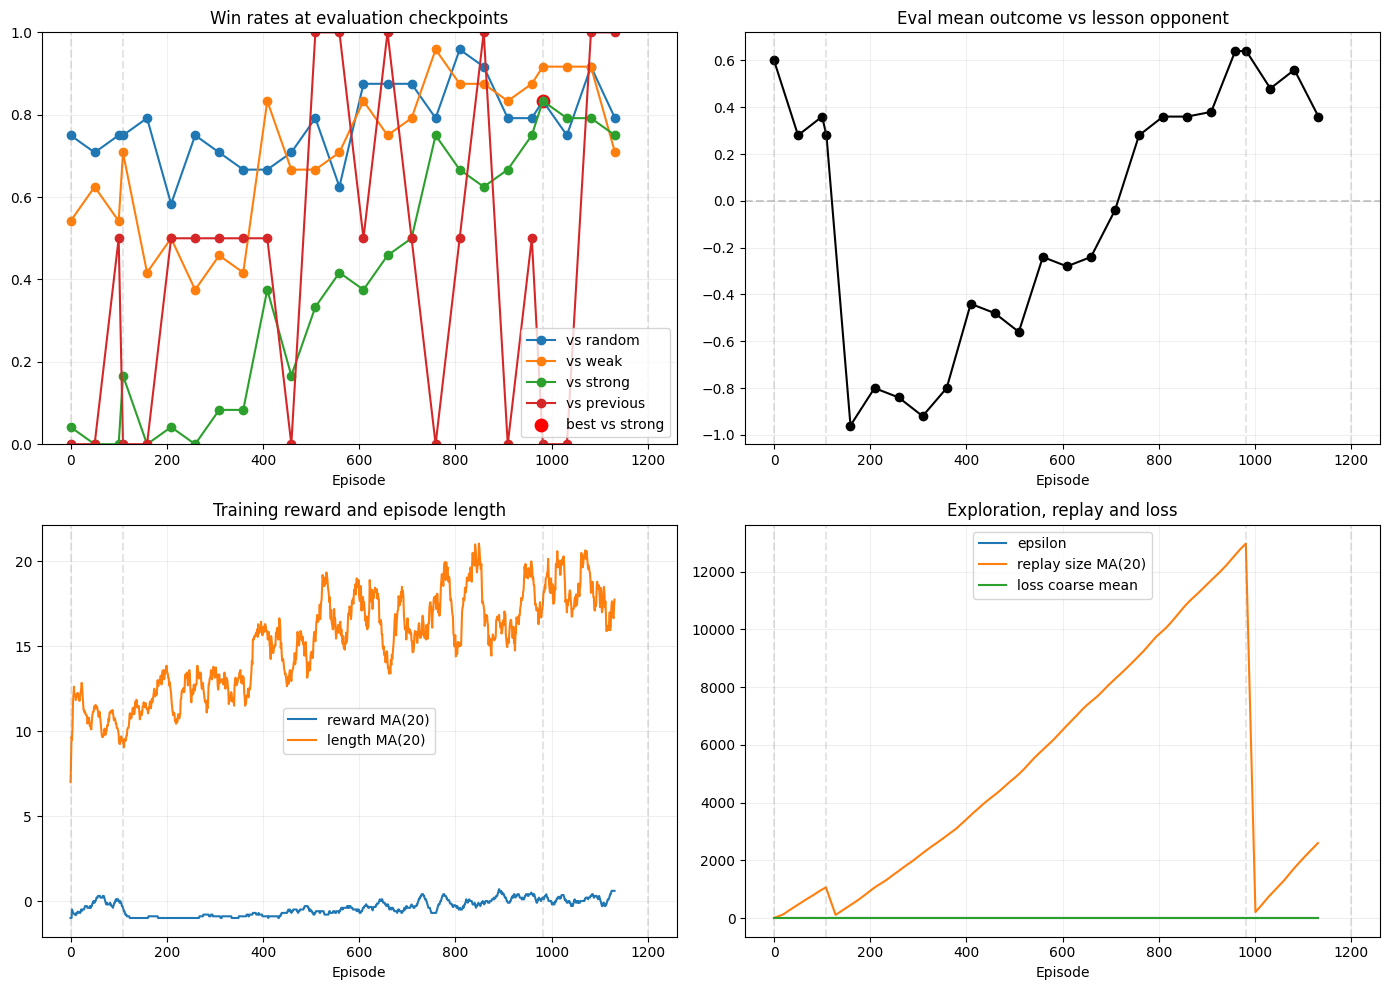

In [5]:
evaluation = getattr(active_metrics, 'evaluation', [])
phase_summary = getattr(active_metrics, 'phase_summary', [])
episode_rewards = getattr(active_metrics, 'episode_rewards', [])
episode_lengths = getattr(active_metrics, 'episode_lengths', [])
epsilons = getattr(active_metrics, 'epsilons', [])
replay_sizes = getattr(active_metrics, 'replay_sizes', [])
losses = getattr(active_metrics, 'losses', [])

def moving_average(values, window):
    if not values:
        return []
    out = []
    for idx in range(len(values)):
        start = max(0, idx - window + 1)
        chunk = values[start:idx + 1]
        out.append(sum(chunk) / len(chunk))
    return out

if evaluation:
    eval_episodes = [int(item['episode']) for item in evaluation]
    eval_outcome = [float(item.get('eval_mean_outcome', 0.0)) for item in evaluation]
    vs_random = [float(item.get('vs_random_win_rate', 0.0)) for item in evaluation]
    vs_weak = [float(item.get('vs_weak_heuristic_win_rate', 0.0)) for item in evaluation]
    vs_strong = [float(item.get('vs_strong_heuristic_win_rate', 0.0)) for item in evaluation]
    vs_previous = [float(item.get('vs_previous_win_rate', 0.0)) for item in evaluation]
    best_vs_strong_idx = max(range(len(vs_strong)), key=lambda idx: vs_strong[idx])
    print('Best vs strong checkpoint')
    print({
        'episode': eval_episodes[best_vs_strong_idx],
        'lesson': evaluation[best_vs_strong_idx].get('lesson_name'),
        'vs_strong': round(vs_strong[best_vs_strong_idx], 4),
        'eval_mean_outcome': round(eval_outcome[best_vs_strong_idx], 4),
        'vs_random': round(vs_random[best_vs_strong_idx], 4),
        'vs_weak': round(vs_weak[best_vs_strong_idx], 4),
    })

    print('Evaluation checkpoints')
    for item in evaluation:
        print({
            'episode': int(item['episode']),
            'lesson': item.get('lesson_name'),
            'eval_mean_outcome': round(float(item.get('eval_mean_outcome', 0.0)), 4),
            'vs_random': round(float(item.get('vs_random_win_rate', 0.0)), 4),
            'vs_weak': round(float(item.get('vs_weak_heuristic_win_rate', 0.0)), 4),
            'vs_strong': round(float(item.get('vs_strong_heuristic_win_rate', 0.0)), 4),
            'vs_previous': round(float(item.get('vs_previous_win_rate', 0.0)), 4),
        })

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    axes[0, 0].plot(eval_episodes, vs_random, marker='o', label='vs random')
    axes[0, 0].plot(eval_episodes, vs_weak, marker='o', label='vs weak')
    axes[0, 0].plot(eval_episodes, vs_strong, marker='o', label='vs strong')
    axes[0, 0].plot(eval_episodes, vs_previous, marker='o', label='vs previous')
    axes[0, 0].scatter([eval_episodes[best_vs_strong_idx]], [vs_strong[best_vs_strong_idx]], color='red', s=80, label='best vs strong')
    axes[0, 0].set_ylim(0.0, 1.0)
    axes[0, 0].set_title('Win rates at evaluation checkpoints')
    axes[0, 0].set_xlabel('Episode')
    axes[0, 0].grid(alpha=0.2)
    axes[0, 0].legend()

    axes[0, 1].plot(eval_episodes, eval_outcome, marker='o', color='black', label='eval mean outcome')
    axes[0, 1].axhline(0.0, color='gray', linestyle='--', alpha=0.4)
    axes[0, 1].set_title('Eval mean outcome vs lesson opponent')
    axes[0, 1].set_xlabel('Episode')
    axes[0, 1].grid(alpha=0.2)

    reward_ma = moving_average(episode_rewards, 20)
    length_ma = moving_average(episode_lengths, 20)
    axes[1, 0].plot(reward_ma, label='reward MA(20)')
    axes[1, 0].plot(length_ma, label='length MA(20)')
    axes[1, 0].set_title('Training reward and episode length')
    axes[1, 0].set_xlabel('Episode')
    axes[1, 0].grid(alpha=0.2)
    axes[1, 0].legend()

    axes[1, 1].plot(epsilons, label='epsilon')
    axes[1, 1].plot(moving_average(replay_sizes, 20), label='replay size MA(20)')
    if losses:
        loss_stride = max(len(losses) // max(len(epsilons), 1), 1)
        loss_series = [sum(losses[i:i + loss_stride]) / len(losses[i:i + loss_stride]) for i in range(0, len(losses), loss_stride)]
        axes[1, 1].plot(loss_series[:len(epsilons)], label='loss coarse mean')
    axes[1, 1].set_title('Exploration, replay and loss')
    axes[1, 1].set_xlabel('Episode')
    axes[1, 1].grid(alpha=0.2)
    axes[1, 1].legend()

    for ax in axes.flat:
        for phase in phase_summary:
            ax.axvline(int(phase['end_episode']), color='gray', linestyle='--', alpha=0.2)

    plt.tight_layout()
    plt.show()
else:
    print('No evaluation history available yet.')


## Passo 6: Avaliação final contra referências

Aqui medimos o agente final contra `random`, `weak`, `strong` e `heuristic` com mais jogos do que no loop de treino.

In [6]:
def evaluate_suite(agent, games: int = 40) -> dict[str, float]:
    return {
        'vs_random': evaluate_against_agent(agent, lambda idx: RandomAgent(seed=10_000 + idx), games=games),
        'vs_weak': evaluate_against_agent(agent, lambda idx: WeakHeuristicAgent(seed=20_000 + idx), games=games),
        'vs_strong': evaluate_against_agent(agent, lambda idx: StrongHeuristicAgent(seed=30_000 + idx), games=games),
        'vs_heuristic': evaluate_against_agent(agent, lambda idx: HeuristicAgent(seed=40_000 + idx), games=games),
    }

summary_eval = evaluate_suite(active_agent, games=40)
summary_eval


{'vs_random': 0.85, 'vs_weak': 0.925, 'vs_strong': 0.95, 'vs_heuristic': 0.825}

## Passo 7: Visualização de partidas

Estas funções imprimem uma partida em ASCII para veres rapidamente que tipo de decisões o agente final está a tomar.

In [7]:
def play_and_render(agent, opponent, controlled_player: int = 1) -> str:
    state = initial_state()
    transcript = ['Initial board', render_ascii(state), '']
    move_idx = 0
    while not is_terminal(state):
        move_idx += 1
        if state.current_player == controlled_player:
            action = agent.select_action(state, legal_actions(state))
            actor = agent.name
        else:
            action = opponent.select_action(state, legal_actions(state))
            actor = opponent.name
        state = apply_action(state, action)
        transcript.append(f'Move {move_idx}: {actor} played column {action}')
        transcript.append(render_ascii(state))
        transcript.append('')
    transcript.append(f'Winner: {state.winner}')
    return '\n'.join(transcript)

print(play_and_render(active_agent, RandomAgent(seed=1), controlled_player=1))


Initial board
. . . . . . .
. . . . . . .
. . . . . . .
. . . . . . .
. . . . . . .
. . . . . . .
0 1 2 3 4 5 6

Move 1: dqn played column 3
. . . . . . .
. . . . . . .
. . . . . . .
. . . . . . .
. . . . . . .
. . . X . . .
0 1 2 3 4 5 6

Move 2: random played column 1
. . . . . . .
. . . . . . .
. . . . . . .
. . . . . . .
. . . . . . .
. O . X . . .
0 1 2 3 4 5 6

Move 3: dqn played column 3
. . . . . . .
. . . . . . .
. . . . . . .
. . . . . . .
. . . X . . .
. O . X . . .
0 1 2 3 4 5 6

Move 4: random played column 4
. . . . . . .
. . . . . . .
. . . . . . .
. . . . . . .
. . . X . . .
. O . X O . .
0 1 2 3 4 5 6

Move 5: dqn played column 4
. . . . . . .
. . . . . . .
. . . . . . .
. . . . . . .
. . . X X . .
. O . X O . .
0 1 2 3 4 5 6

Move 6: random played column 6
. . . . . . .
. . . . . . .
. . . . . . .
. . . . . . .
. . . X X . .
. O . X O . O
0 1 2 3 4 5 6

Move 7: dqn played column 4
. . . . . . .
. . . . . . .
. . . . . . .
. . . . X . .
. . . X X . .
. O . X O . O
0 1 

In [8]:
print(play_and_render(active_agent, HeuristicAgent(seed=2), controlled_player=1))


Initial board
. . . . . . .
. . . . . . .
. . . . . . .
. . . . . . .
. . . . . . .
. . . . . . .
0 1 2 3 4 5 6

Move 1: dqn played column 3
. . . . . . .
. . . . . . .
. . . . . . .
. . . . . . .
. . . . . . .
. . . X . . .
0 1 2 3 4 5 6

Move 2: heuristic played column 6
. . . . . . .
. . . . . . .
. . . . . . .
. . . . . . .
. . . . . . .
. . . X . . O
0 1 2 3 4 5 6

Move 3: dqn played column 3
. . . . . . .
. . . . . . .
. . . . . . .
. . . . . . .
. . . X . . .
. . . X . . O
0 1 2 3 4 5 6

Move 4: heuristic played column 5
. . . . . . .
. . . . . . .
. . . . . . .
. . . . . . .
. . . X . . .
. . . X . O O
0 1 2 3 4 5 6

Move 5: dqn played column 2
. . . . . . .
. . . . . . .
. . . . . . .
. . . . . . .
. . . X . . .
. . X X . O O
0 1 2 3 4 5 6

Move 6: heuristic played column 4
. . . . . . .
. . . . . . .
. . . . . . .
. . . . . . .
. . . X . . .
. . X X O O O
0 1 2 3 4 5 6

Move 7: dqn played column 4
. . . . . . .
. . . . . . .
. . . . . . .
. . . . . . .
. . . X X . .
. . X X O